# Baseline Decision Tree - Task B Only

Deteccion de tipo de clon (`type_I`, `type_II`, `type_III`, `type_IV`) con arbol de decision.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable
import io
import random
import re
import tokenize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier


In [2]:
# configuracion general
SEED = 42
ESTRATEGIA_BALANCEO = 'undersample'  # none, undersample, oversample

random.seed(SEED)
np.random.seed(SEED)

RUTA_BASE = Path.cwd()
if (RUTA_BASE / 'clone_pairs_dataset_metadata.csv').exists():
    RUTA_DATASET = RUTA_BASE
else:
    RUTA_DATASET = RUTA_BASE / 'DataBaseProject'

RUTA_METADATA = RUTA_DATASET / 'clone_pairs_dataset_metadata.csv'
RUTA_PARES = RUTA_DATASET / 'pares_clones'

print('RUTA_DATASET:', RUTA_DATASET)
print('RUTA_METADATA:', RUTA_METADATA)
print('RUTA_PARES:', RUTA_PARES)
print('ESTRATEGIA_BALANCEO:', ESTRATEGIA_BALANCEO)


RUTA_DATASET: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject
RUTA_METADATA: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject\clone_pairs_dataset_metadata.csv
RUTA_PARES: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject\pares_clones
ESTRATEGIA_BALANCEO: undersample


In [3]:
COLUMNAS_METADATA = [
    'is_clone', 'clone_type', 'source_group', 'filename', 'file_path',
    'problem_id', 'snippet_index_a', 'snippet_index_b'
]

PATRON_MARCADOR_LENGUAJE = re.compile(r'^\s*(python|java|javascript|c\+\+|cpp|ruby|go)\s*$', flags=re.IGNORECASE | re.MULTILINE)
PATRON_SEPARADOR_SNIPPETS = re.compile(r'\n\s*\n\s*\n+')
PATRON_ESPACIOS = re.compile(r'[ \t]+')
PATRON_SALTOS = re.compile(r'\n{3,}')

@dataclass
class ResultadoSplit:
    train_idx: pd.Index
    val_idx: pd.Index
    test_idx: pd.Index


In [4]:
def cargar_metadata(ruta_csv: Path) -> pd.DataFrame:
    return pd.read_csv(ruta_csv)

def limpiar_metadata(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[COLUMNAS_METADATA].copy()
    out['is_clone'] = pd.to_numeric(out['is_clone'], errors='coerce')
    out['problem_id'] = pd.to_numeric(out['problem_id'], errors='coerce')
    out['snippet_index_a'] = pd.to_numeric(out['snippet_index_a'], errors='coerce')
    out['snippet_index_b'] = pd.to_numeric(out['snippet_index_b'], errors='coerce')
    out = out.dropna(subset=['is_clone', 'clone_type', 'file_path', 'problem_id', 'snippet_index_a', 'snippet_index_b']).copy()
    out['is_clone'] = out['is_clone'].astype(int)
    out['problem_id'] = out['problem_id'].astype(int)
    out['snippet_index_a'] = out['snippet_index_a'].astype(int)
    out['snippet_index_b'] = out['snippet_index_b'].astype(int)
    out = out[out['is_clone'] == 1].copy()
    return out

def separar_snippets(texto_archivo: str) -> list[str]:
    texto = texto_archivo.replace('\r\n', '\n').replace('\r', '\n').strip()
    if not texto:
        return []
    bloques = [b.strip() for b in PATRON_MARCADOR_LENGUAJE.split(texto) if b.strip()]
    snippets = []
    for bloque in bloques:
        partes = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(bloque) if p.strip()]
        if len(partes) > 1:
            snippets.extend(partes)
        else:
            snippets.append(bloque)
    if len(snippets) < 2:
        fallback = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]
        if len(fallback) > len(snippets):
            snippets = fallback
    return snippets

def normalizar_ruta_relativa(ruta: str) -> Path:
    return Path(str(ruta).replace('\\', '/'))

def reconstruir_pares(df_metadata: pd.DataFrame, ruta_dataset: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    filas_ok = []
    filas_drop = []
    cache_snippets = {}
    for fila in df_metadata.itertuples(index=False):
        ruta_rel = normalizar_ruta_relativa(str(fila.file_path))
        ruta_abs = ruta_dataset / ruta_rel
        clave = str(ruta_rel).lower()
        if clave not in cache_snippets:
            if not ruta_abs.exists():
                cache_snippets[clave] = None
            else:
                texto = ruta_abs.read_text(encoding='utf-8', errors='replace')
                cache_snippets[clave] = separar_snippets(texto)

        snippets = cache_snippets[clave]
        if snippets is None:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'file_not_found'})
            continue

        idx_a = int(fila.snippet_index_a)
        idx_b = int(fila.snippet_index_b)
        if idx_a < 0 or idx_b < 0:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'negative_snippet_index'})
            continue
        if idx_a >= len(snippets) or idx_b >= len(snippets):
            filas_drop.append({**fila._asdict(), 'drop_reason': 'snippet_index_out_of_range'})
            continue

        filas_ok.append({
            **fila._asdict(),
            'resolved_path': str(ruta_abs),
            'snippet_count': len(snippets),
            'code_a': snippets[idx_a],
            'code_b': snippets[idx_b],
        })

    df_ok = pd.DataFrame(filas_ok)
    df_drop = pd.DataFrame(filas_drop)
    resumen = {
        'metadata_rows': int(len(df_metadata)),
        'reconstructed_rows': int(len(df_ok)),
        'dropped_rows': int(len(df_drop)),
    }
    return df_ok, df_drop, resumen


In [5]:
def split_por_grupo(df: pd.DataFrame, group_col: str, target_col: str, seed: int = 42, train_size: float = 0.7, val_size: float = 0.15, test_size: float = 0.15) -> ResultadoSplit:
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp
    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    return ResultadoSplit(train_idx=df.index[idx_train_np], val_idx=df_temp.index[idx_val_rel], test_idx=df_temp.index[idx_test_rel])

def asignar_split(df, idx_train, idx_val, idx_test, nombre_columna='split'):
    datos = df.copy()
    datos[nombre_columna] = 'unassigned'
    datos.loc[idx_train, nombre_columna] = 'train'
    datos.loc[idx_val, nombre_columna] = 'val'
    datos.loc[idx_test, nombre_columna] = 'test'
    return datos

def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    resumen = []
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append({'split': nombre_split, 'rows': int(len(df_split)), 'unique_groups': int(df_split[group_col].nunique()), 'class_distribution': {str(k): int(v) for k, v in conteos.items()}})
    return resumen

def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = 'none', seed: int = 42):
    conteos = df_train[target_col].value_counts()
    info = {'strategy': estrategia, 'target_col': target_col, 'rows_before': int(len(df_train)), 'class_distribution_before': {str(k): int(v) for k, v in conteos.items()}}

    if estrategia == 'none' or len(conteos) <= 1:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    if estrategia == 'undersample':
        n_obj = int(conteos.min())
        rep = False
    elif estrategia == 'oversample':
        n_obj = int(conteos.max())
        rep = True
    else:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    partes = []
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info['rows_after'] = int(len(out))
    info['class_distribution_after'] = {str(k): int(v) for k, v in c2.items()}
    return out, info


In [6]:
def quitar_comentarios(codigo: str) -> str:
    if not codigo.strip():
        return codigo
    try:
        salida = []
        lector = io.StringIO(codigo).readline
        for tok in tokenize.generate_tokens(lector):
            if tok.type == tokenize.COMMENT:
                continue
            salida.append(tok)
        return tokenize.untokenize(salida)
    except (tokenize.TokenError, IndentationError):
        return codigo

def normalizar_espacios(codigo: str) -> str:
    lineas = []
    for linea in codigo.splitlines():
        compacta = PATRON_ESPACIOS.sub(' ', linea).rstrip()
        lineas.append(compacta)
    normalizado = '\n'.join(lineas).strip()
    normalizado = PATRON_SALTOS.sub('\n\n', normalizado)
    return normalizado

def preprocesar_codigo(codigo: str) -> str:
    return normalizar_espacios(quitar_comentarios(codigo))

def tokenizar_python(codigo: str) -> list[str]:
    if not codigo.strip():
        return []
    try:
        tokens = []
        lector = io.StringIO(codigo).readline
        excluir = {tokenize.ENCODING, tokenize.ENDMARKER, tokenize.NL, tokenize.NEWLINE, tokenize.INDENT, tokenize.DEDENT, tokenize.COMMENT}
        for tok in tokenize.generate_tokens(lector):
            if tok.type in excluir:
                continue
            t = tok.string.strip()
            if t:
                tokens.append(t)
        return tokens
    except (tokenize.TokenError, IndentationError):
        return re.findall(r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[-+*/%=<>()[\]{}.,:;]', codigo)

def preparar_campos_par(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    code_a_clean = [preprocesar_codigo(x) for x in out['code_a'].astype(str)]
    code_b_clean = [preprocesar_codigo(x) for x in out['code_b'].astype(str)]
    tokens_a = [tokenizar_python(x) for x in code_a_clean]
    tokens_b = [tokenizar_python(x) for x in code_b_clean]
    out['code_a_clean'] = code_a_clean
    out['code_b_clean'] = code_b_clean
    out['tokens_a'] = tokens_a
    out['tokens_b'] = tokens_b
    out['token_text_a'] = [' '.join(t) for t in tokens_a]
    out['token_text_b'] = [' '.join(t) for t in tokens_b]
    return out

def similitud_jaccard(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return float(len(set_a & set_b) / len(union))

def similitud_dice(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    denom = len(set_a) + len(set_b)
    if denom == 0:
        return 0.0
    return float(2.0 * len(set_a & set_b) / denom)

def ratio_overlap(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    min_size = min(len(set_a), len(set_b))
    if min_size == 0:
        return 0.0
    return float(len(set_a & set_b) / min_size)

def ajustar_tfidf(df_train: pd.DataFrame) -> TfidfVectorizer:
    corpus = pd.concat([df_train['token_text_a'], df_train['token_text_b']], axis=0)
    vector = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=1)
    vector.fit(corpus)
    return vector

def coseno_fila_a_fila(mat_a: sparse.spmatrix, mat_b: sparse.spmatrix) -> np.ndarray:
    producto = np.asarray(mat_a.multiply(mat_b).sum(axis=1)).ravel()
    norma_a = np.sqrt(np.asarray(mat_a.multiply(mat_a).sum(axis=1)).ravel())
    norma_b = np.sqrt(np.asarray(mat_b.multiply(mat_b).sum(axis=1)).ravel())
    denom = norma_a * norma_b
    denom[denom == 0.0] = 1e-12
    return producto / denom

def construir_features_par(df: pd.DataFrame, vector: TfidfVectorizer) -> pd.DataFrame:
    mat_a = vector.transform(df['token_text_a'])
    mat_b = vector.transform(df['token_text_b'])
    coseno = coseno_fila_a_fila(mat_a, mat_b)

    chars_a = df['code_a_clean'].str.len().astype(float)
    chars_b = df['code_b_clean'].str.len().astype(float)
    lineas_a = df['code_a_clean'].str.count('\n').astype(float) + 1.0
    lineas_b = df['code_b_clean'].str.count('\n').astype(float) + 1.0
    tokens_a = df['tokens_a'].apply(len).astype(float)
    tokens_b = df['tokens_b'].apply(len).astype(float)

    jaccard = [similitud_jaccard(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    dice = [similitud_dice(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    overlap = [ratio_overlap(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]

    return pd.DataFrame({
        'cosine_tfidf': coseno,
        'jaccard_tokens': jaccard,
        'dice_tokens': dice,
        'overlap_unique_tokens': overlap,
        'char_len_a': chars_a,
        'char_len_b': chars_b,
        'char_len_diff': (chars_a - chars_b).abs(),
        'line_count_a': lineas_a,
        'line_count_b': lineas_b,
        'line_count_diff': (lineas_a - lineas_b).abs(),
        'token_count_a': tokens_a,
        'token_count_b': tokens_b,
        'token_count_diff': (tokens_a - tokens_b).abs(),
    }, index=df.index)


In [7]:
def evaluar_predicciones(y_true, y_pred, labels: list, y_proba=None) -> dict[str, Any]:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    reporte_texto = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_w),
        'recall_weighted': float(r_w),
        'f1_weighted': float(f1_w),
        'confusion_matrix': cm.tolist(),
        'classification_report_dict': reporte_dict,
        'classification_report_text': reporte_texto,
    }


def graficar_hist_balanceo(info_balanceo: dict, titulo: str):
    antes = info_balanceo.get('class_distribution_before', {})
    despues = info_balanceo.get('class_distribution_after', {})
    clases = sorted(set(list(antes.keys()) + list(despues.keys())))
    y_antes = [antes.get(c, 0) for c in clases]
    y_despues = [despues.get(c, 0) for c in clases]

    x = np.arange(len(clases))
    w = 0.38
    plt.figure(figsize=(8, 4))
    plt.bar(x - w / 2, y_antes, width=w, label='Antes', color='#4C78A8')
    plt.bar(x + w / 2, y_despues, width=w, label='Despues', color='#E45756')
    plt.xticks(x, clases)
    plt.title(titulo)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.legend()
    plt.tight_layout()
    plt.show()

def entrenar_evaluar_decision_tree(datos_task, columna_target, etiquetas, seed, estrategia_balanceo='none'):
    train_raw = datos_task[datos_task['split'] == 'train'].copy()
    val = datos_task[datos_task['split'] == 'val'].copy()
    test = datos_task[datos_task['split'] == 'test'].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)
    graficar_hist_balanceo(info_balanceo, 'Histograma balanceo train - Task B')

    vector_tfidf = ajustar_tfidf(train_balanceado)
    X_train = construir_features_par(train_balanceado, vector_tfidf)
    X_val = construir_features_par(val, vector_tfidf)
    X_test = construir_features_par(test, vector_tfidf)

    model = DecisionTreeClassifier(criterion='gini', max_depth=12, min_samples_leaf=2, class_weight='balanced', random_state=seed)
    model.fit(X_train, train_balanceado[columna_target])

    y_val = val[columna_target]
    y_test = test[columna_target]
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    proba_val = model.predict_proba(X_val)
    proba_test = model.predict_proba(X_test)

    metricas_val = evaluar_predicciones(y_val, pred_val, labels=etiquetas, y_proba=proba_val)
    metricas_test = evaluar_predicciones(y_test, pred_test, labels=etiquetas, y_proba=proba_test)

    print('--- Balanceo train ---')
    print(info_balanceo)
    print('')
    print('--- Metricas VAL ---')
    print('accuracy:', round(metricas_val['accuracy'], 4))
    print('f1_macro:', round(metricas_val['f1_macro'], 4))
    print('')
    print('--- Metricas TEST ---')
    print('accuracy:', round(metricas_test['accuracy'], 4))
    print('f1_macro:', round(metricas_test['f1_macro'], 4))
    print('')
    print('Reporte TEST:')
    print(metricas_test['classification_report_text'])

    cm_val = np.array(metricas_val['confusion_matrix'])
    cm_test = np.array(metricas_test['confusion_matrix'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay(cm_val, display_labels=[str(x) for x in etiquetas]).plot(ax=axes[0], colorbar=False)
    axes[0].set_title('Task B - Matriz VAL')
    ConfusionMatrixDisplay(cm_test, display_labels=[str(x) for x in etiquetas]).plot(ax=axes[1], colorbar=False)
    axes[1].set_title('Task B - Matriz TEST')
    plt.tight_layout()
    plt.show()

    return {'info_balanceo': info_balanceo, 'metricas_val': metricas_val, 'metricas_test': metricas_test, 'modelo': model}


In [8]:
# 1) carga y validacion de metadata
datos_metadata = cargar_metadata(RUTA_METADATA)
datos_metadata_limpios = limpiar_metadata(datos_metadata)

print('Filas metadata:', len(datos_metadata))
print('Filas limpias (solo clones):', len(datos_metadata_limpios))
print('Distribucion clone_type en metadata limpia:')
print(datos_metadata_limpios['clone_type'].value_counts().sort_index())


Filas metadata: 8400
Filas limpias (solo clones): 8400
Distribucion clone_type en metadata limpia:
clone_type
type_I      2100
type_II     2100
type_III    2100
type_IV     2100
Name: count, dtype: int64


In [9]:
# 2) reconstruccion de pares desde archivos
datos_reconstruidos, datos_descartados, resumen_reconstruccion = reconstruir_pares(datos_metadata_limpios, RUTA_DATASET)
print('Resumen reconstruccion:', resumen_reconstruccion)
if len(datos_descartados) > 0:
    print('Descartados por motivo:')
    print(datos_descartados['drop_reason'].value_counts())

datos_preparados = preparar_campos_par(datos_reconstruidos)
print('Filas listas para modelado:', len(datos_preparados))


Resumen reconstruccion: {'metadata_rows': 8400, 'reconstructed_rows': 8400, 'dropped_rows': 0}


Filas listas para modelado: 8400


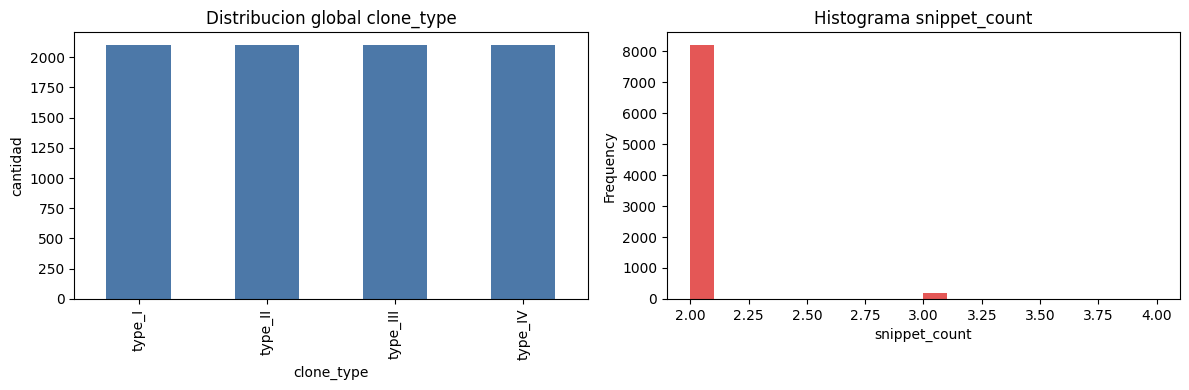

In [10]:
# 3) visualizaciones de distribucion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datos_preparados['clone_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribucion global clone_type')
axes[0].set_xlabel('clone_type')
axes[0].set_ylabel('cantidad')

datos_preparados['snippet_count'].plot(kind='hist', bins=20, ax=axes[1], color='#E45756')
axes[1].set_title('Histograma snippet_count')
axes[1].set_xlabel('snippet_count')
plt.tight_layout()
plt.show()


Estadisticas split Task B:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


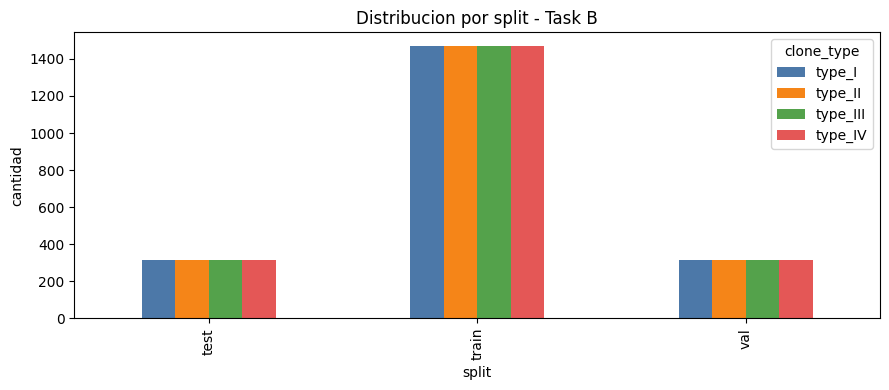

In [11]:
# 4) split Task B por grupo
split_task_b = split_por_grupo(
    df=datos_preparados,
    group_col='problem_id',
    target_col='clone_type',
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

datos_task_b = asignar_split(datos_preparados, split_task_b.train_idx, split_task_b.val_idx, split_task_b.test_idx)

print('Estadisticas split Task B:')
stats_b = estadisticas_split(datos_task_b, 'split', 'clone_type', 'problem_id')
for fila in stats_b:
    print(fila)

conteos_split_b = datos_task_b.groupby(['split', 'clone_type']).size().unstack(fill_value=0)
conteos_split_b.plot(kind='bar', figsize=(9, 4), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('Distribucion por split - Task B')
plt.xlabel('split')
plt.ylabel('cantidad')
plt.tight_layout()
plt.show()


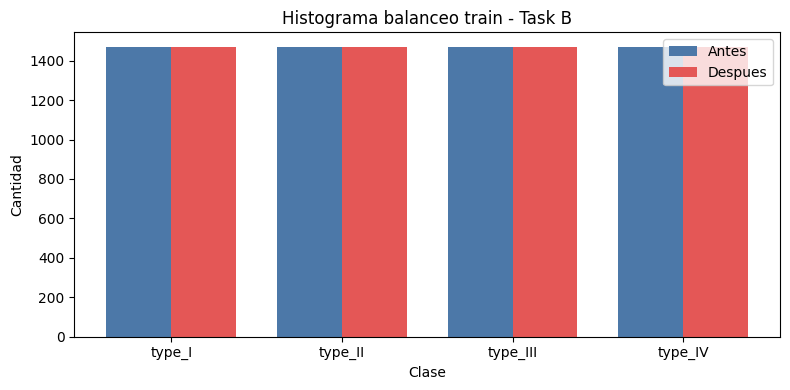

--- Balanceo train ---
{'strategy': 'undersample', 'target_col': 'clone_type', 'rows_before': 5880, 'class_distribution_before': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}, 'rows_after': 5880, 'class_distribution_after': {'type_IV': 1470, 'type_III': 1470, 'type_I': 1470, 'type_II': 1470}}

--- Metricas VAL ---
accuracy: 0.85
f1_macro: 0.8492

--- Metricas TEST ---
accuracy: 0.8587
f1_macro: 0.858

Reporte TEST:
              precision    recall  f1-score   support

      type_I       0.98      1.00      0.99       315
     type_II       0.97      0.97      0.97       315
    type_III       0.73      0.75      0.74       315
     type_IV       0.76      0.71      0.73       315

    accuracy                           0.86      1260
   macro avg       0.86      0.86      0.86      1260
weighted avg       0.86      0.86      0.86      1260



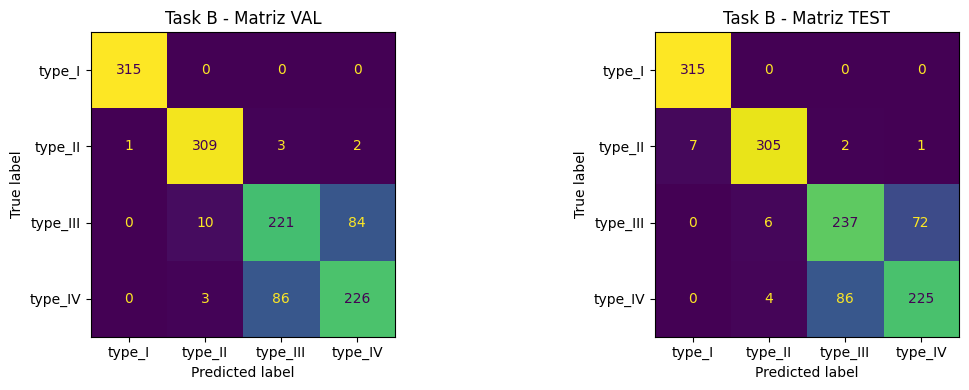

In [12]:
# 5) entrenamiento y evaluacion Task B
etiquetas_task_b = sorted(datos_task_b['clone_type'].unique().tolist())
resultado_task_b = entrenar_evaluar_decision_tree(
    datos_task_b,
    columna_target='clone_type',
    etiquetas=etiquetas_task_b,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
)


In [13]:
# 6) resumen final
resumen_final = pd.DataFrame([{
    'tarea': 'Task B - clone_type',
    'accuracy_val': resultado_task_b['metricas_val']['accuracy'],
    'f1_macro_val': resultado_task_b['metricas_val']['f1_macro'],
    'accuracy_test': resultado_task_b['metricas_test']['accuracy'],
    'f1_macro_test': resultado_task_b['metricas_test']['f1_macro'],
}])

print('Resumen final:')
display(resumen_final)


Resumen final:


,tarea,accuracy_val,f1_macro_val,accuracy_test,f1_macro_test
0,Task B - clone_type,0.85,0.84917,0.85873,0.857996
